In [29]:
# Section 0 — Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr, pearsonr
from scipy.optimize import curve_fit


In [30]:
# Section 1 — Mount Drive and load processed Parquet/CSV files
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from scipy.optimize import curve_fit

# ---------------------------------------------------------------------
# Actual processed-data paths
# ---------------------------------------------------------------------

CALCE_PROC = Path(
    "/content/drive/MyDrive/Colab Notebooks/A123_Parquet/processed"
)

OXFORD_PROC = Path(
    "/content/drive/MyDrive/Colab Notebooks/Battery Data/"
    "Oxford Battery Degradation Dataset 1/processed"
)

# Output folder for final manuscript-ready results
OUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Paper_Final_Results"
)

FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("CALCE processed path :", CALCE_PROC)
print("Oxford processed path:", OXFORD_PROC)
print("Output path          :", OUT_DIR)


CALCE processed path : /content/drive/MyDrive/Colab Notebooks/A123_Parquet/processed
Oxford processed path: /content/drive/MyDrive/Colab Notebooks/Battery Data/Oxford Battery Degradation Dataset 1/processed
Output path          : /content/drive/MyDrive/Colab Notebooks/Paper_Final_Results


In [32]:
# ---------------------------------------------------------------------
# Oxford / Kokam processed files
# ---------------------------------------------------------------------

ox_desc = pd.read_parquet(OXFORD_PROC / "oxford_descriptors.parquet")
ox_local = pd.read_parquet(OXFORD_PROC / "oxford_descriptors_local.parquet")
ox_unc = pd.read_parquet(OXFORD_PROC / "oxford_descriptors_with_uncertainty.parquet")
ox_gp = pd.read_csv(OXFORD_PROC / "oxford_gp_metrics.csv")

# Optional but useful for manuscript figures / checks
ox_ref = pd.read_parquet(OXFORD_PROC / "oxford_reference_curves.parquet")
ox_defo = pd.read_parquet(OXFORD_PROC / "oxford_deformation_profiles.parquet")
ox_qc = pd.read_parquet(OXFORD_PROC / "oxford_qc_flags.parquet")

# ---------------------------------------------------------------------
# CALCE / A123 processed files
# ---------------------------------------------------------------------

ca_desc = pd.read_parquet(CALCE_PROC / "a123_descriptors.parquet")
ca_local = pd.read_parquet(CALCE_PROC / "a123_descriptors_local.parquet")
ca_unc = pd.read_parquet(CALCE_PROC / "a123_descriptors_with_uncertainty.parquet")
ca_gp = pd.read_csv(CALCE_PROC / "a123_gp_metrics.csv")

# Optional but useful for manuscript figures / checks
ca_ref = pd.read_parquet(CALCE_PROC / "a123_reference_curves.parquet")
ca_defo = pd.read_parquet(CALCE_PROC / "a123_deformation_profiles.parquet")

# ---------------------------------------------------------------------
# Quick inventory
# ---------------------------------------------------------------------

print("Oxford descriptor rows :", len(ox_desc))
print("Oxford local rows      :", len(ox_local))
print("Oxford uncertainty rows:", len(ox_unc))
print("Oxford GP metric rows  :", len(ox_gp))
print()
print("CALCE descriptor rows  :", len(ca_desc))
print("CALCE local rows       :", len(ca_local))
print("CALCE uncertainty rows :", len(ca_unc))
print("CALCE GP metric rows   :", len(ca_gp))


Oxford descriptor rows : 504
Oxford local rows      : 49896
Oxford uncertainty rows: 80
Oxford GP metric rows  : 8

CALCE descriptor rows  : 16
CALCE local rows       : 1584
CALCE uncertainty rows : 20
CALCE GP metric rows   : 4


In [33]:
print("Oxford descriptor columns:")
print(ox_desc.columns.tolist())

print("\nCALCE descriptor columns:")
print(ca_desc.columns.tolist())

print("\nOxford uncertainty columns:")
print(ox_unc.columns.tolist())

print("\nCALCE uncertainty columns:")
print(ca_unc.columns.tolist())


Oxford descriptor columns:
['cell_id', 'cycle_key', 'cycle_number', 'soh', 'd1_mean_drift_v', 'd1_mean_drift_norm', 'd3_plateau_center', 'd3_plateau_width', 'd3_plateau_shift', 'd4_a_slope_mean', 'd5_peak_soc', 'd5_peak_amp_v', 'd6_ndi_r', 'd6_ndi_rms']

CALCE descriptor columns:
['cell_id', 'temperature_c', 'd1_mean_drift_v', 'd1_mean_drift_norm', 'd3_plateau_center', 'd3_plateau_width', 'd3_plateau_shift', 'd4_a_slope_mean', 'd5_peak_soc', 'd5_peak_amp_v', 'd6_ndi_r', 'd6_ndi_rms']

Oxford uncertainty columns:
['cell_id', 'soh', 'ndi_mean', 'ndi_ci_lo', 'ndi_ci_hi', 'plateau_mean', 'plateau_ci_lo', 'plateau_ci_hi', 'a_slope_mean', 'a_slope_ci_lo', 'a_slope_ci_hi']

CALCE uncertainty columns:
['cell_id', 'temperature_c', 'ndi_mean', 'ndi_ci_lo', 'ndi_ci_hi', 'plateau_mean', 'plateau_ci_lo', 'plateau_ci_hi', 'a_slope_mean', 'a_slope_ci_lo', 'a_slope_ci_hi']


In [34]:
# Section 2 — Enforce corrected D6 definition: use RMS-normalized NDIR
# ---------------------------------------------------------------------
# Official manuscript D6 column
# ---------------------------------------------------------------------

D6_COL = "d6_ndi_rms"

required_cols = [
    "d6_ndi_r",
    "d6_ndi_rms",
]

for col in required_cols:
    assert col in ox_desc.columns, f"Missing Oxford column: {col}"
    assert col in ca_desc.columns, f"Missing CALCE column: {col}"

print(f"Official D6 descriptor for final manuscript: {D6_COL}")


Official D6 descriptor for final manuscript: d6_ndi_rms


In [35]:
# ---------------------------------------------------------------------
# Optional: rename for readability in this final notebook
# ---------------------------------------------------------------------

ox_desc = ox_desc.copy()
ca_desc = ca_desc.copy()

ox_desc["d6_ndir_rms"] = ox_desc["d6_ndi_rms"]
ca_desc["d6_ndir_rms"] = ca_desc["d6_ndi_rms"]

D6_COL = "d6_ndir_rms"

print("Using:", D6_COL)


Using: d6_ndir_rms


In [36]:
# Section 3 — NDIR audit table
# ---------------------------------------------------------------------
# NDIR audit: L2-normalized vs RMS-normalized
# ---------------------------------------------------------------------

N_SOC = 99
EXPECTED_RATIO = np.sqrt(N_SOC)

def ndir_audit(df, dataset_name):
    ratio = df["d6_ndi_r"] / df["d6_ndi_rms"]
    ratio = ratio.replace([np.inf, -np.inf], np.nan).dropna()

    return {
        "dataset": dataset_name,
        "n_rows": len(df),
        "expected_sqrt_N": EXPECTED_RATIO,
        "median_L2_over_RMS": ratio.median(),
        "mean_L2_over_RMS": ratio.mean(),
        "std_L2_over_RMS": ratio.std(),
        "max_NDI_L2": df["d6_ndi_r"].max(),
        "max_NDIR_RMS": df["d6_ndi_rms"].max(),
    }

ndir_audit_df = pd.DataFrame([
    ndir_audit(ox_desc, "Oxford Kokam"),
    ndir_audit(ca_desc, "CALCE A123"),
])

ndir_audit_df.to_csv(TABLE_DIR / "ndir_l2_vs_rms_audit.csv", index=False)

ndir_audit_df


,dataset,n_rows,expected_sqrt_N,median_L2_over_RMS,mean_L2_over_RMS,std_L2_over_RMS,max_NDI_L2,max_NDIR_RMS
0,Oxford Kokam,504,9.949874,9.949874,9.949874,1.614868e-14,0.410105,0.041217
1,CALCE A123,16,9.949874,9.949874,9.949874,1.101650e-15,2.395270,0.240734


In [37]:
print("NDIR audit summary:")
for _, row in ndir_audit_df.iterrows():
    print(
        f"{row['dataset']}: "
        f"median L2/RMS = {row['median_L2_over_RMS']:.3f}, "
        f"expected sqrt(99) = {row['expected_sqrt_N']:.3f}"
    )


NDIR audit summary:
Oxford Kokam: median L2/RMS = 9.950, expected sqrt(99) = 9.950
CALCE A123: median L2/RMS = 9.950, expected sqrt(99) = 9.950


In [38]:
# Section 4 — Define severity variables
T_REF = 25
T_MIN = -10
CALCE_COLD_SPAN = T_REF - T_MIN  # 35 °C

# ---------------------------------------------------------------------
# Oxford severity
# ---------------------------------------------------------------------

ox_desc["severity"] = 1.0 - ox_desc["soh"]
ox_desc["severity_norm"] = ox_desc["severity"] / ox_desc["severity"].max()
ox_desc["dataset"] = "Oxford Kokam"

# ---------------------------------------------------------------------
# CALCE cold-side severity
# ---------------------------------------------------------------------

ca_cold = ca_desc[ca_desc["temperature_c"] < T_REF].copy()
ca_cold["severity"] = T_REF - ca_cold["temperature_c"]
ca_cold["severity_norm"] = ca_cold["severity"] / CALCE_COLD_SPAN
ca_cold["dataset"] = "CALCE A123"

print(
    f"Oxford severity range: "
    f"{ox_desc['severity'].min():.4f} – {ox_desc['severity'].max():.4f}"
)

print(
    f"CALCE cold-side severity range: "
    f"{ca_cold['severity'].min():.1f} – {ca_cold['severity'].max():.1f} °C"
)

print()
print(f"Oxford rows         : {len(ox_desc)}")
print(f"CALCE cold-side rows: {len(ca_cold)}")


Oxford severity range: 0.0000 – 0.2431
CALCE cold-side severity range: 5.0 – 35.0 °C

Oxford rows         : 504
CALCE cold-side rows: 8


In [39]:
# Section 5 — Criterion 1: direction of descriptor evolution
SCALAR_DESCRIPTORS = [
    "d1_mean_drift_v",
    "d3_plateau_center",
    "d3_plateau_width",
    "d3_plateau_shift",
    "d4_a_slope_mean",
    "d5_peak_soc",
    "d5_peak_amp_v",
    D6_COL,
]

descriptor_labels = {
    "d1_mean_drift_v": "D1 mean drift",
    "d3_plateau_center": "D3a low-slope center",
    "d3_plateau_width": "D3b low-slope width",
    "d3_plateau_shift": "D3c low-slope shift",
    "d4_a_slope_mean": "D4 slope amplification",
    "d5_peak_soc": "D5a peak |ΔU| SOC",
    "d5_peak_amp_v": "D5b signed peak amplitude",
    D6_COL: r"D6 NDIR$_{RMS}$",
}


In [40]:
rows = []

for desc in SCALAR_DESCRIPTORS:
    ox_clean = ox_desc.dropna(subset=[desc, "severity"])
    ca_clean = ca_cold.dropna(subset=[desc, "severity"])

    rho_ox, p_ox = spearmanr(ox_clean[desc], ox_clean["severity"])
    rho_ca, p_ca = spearmanr(ca_clean[desc], ca_clean["severity"])

    same_sign = np.sign(rho_ox) == np.sign(rho_ca)
    both_sig = (p_ox < 0.05) and (p_ca < 0.05)

    if same_sign and both_sig:
        verdict = "aligned"
    elif (not same_sign) and both_sig:
        verdict = "opposite"
    else:
        verdict = "inconclusive"

    rows.append({
        "descriptor": desc,
        "descriptor_label": descriptor_labels.get(desc, desc),
        "oxford_rho": rho_ox,
        "oxford_p": p_ox,
        "calce_rho": rho_ca,
        "calce_p": p_ca,
        "same_sign": same_sign,
        "both_significant": both_sig,
        "criterion1_verdict": verdict,
        "n_oxford": len(ox_clean),
        "n_calce_cold": len(ca_clean),
    })

crit1_df = pd.DataFrame(rows)

crit1_df.to_csv(TABLE_DIR / "criterion1_direction_ndir_rms.csv", index=False)

crit1_df


,descriptor,descriptor_label,oxford_rho,oxford_p,calce_rho,calce_p,same_sign,both_significant,criterion1_verdict,n_oxford,n_calce_cold
0,d1_mean_drift_v,D1 mean drift,0.952627,1.188515e-261,-0.975900,0.000034,False,True,opposite,504,8
1,d3_plateau_center,D3a low-slope center,-0.961028,1.823759e-282,0.683130,0.061835,False,False,inconclusive,504,8
2,d3_plateau_width,D3b low-slope width,0.888415,7.116025e-172,0.687233,0.059669,True,False,inconclusive,504,8
3,d3_plateau_shift,D3c low-slope shift,-0.961028,1.823759e-282,0.683130,0.061835,False,False,inconclusive,504,8
4,d4_a_slope_mean,D4 slope amplification,0.966467,1.492856e-298,0.975900,0.000034,True,True,aligned,504,8
5,d5_peak_soc,D5a peak |ΔU| SOC,-0.427979,1.646779e-23,-0.843274,0.008528,True,True,aligned,496,8
6,d5_peak_amp_v,D5b signed peak amplitude,0.939848,1.365990e-232,-0.975900,0.000034,False,True,opposite,496,8
7,d6_ndir_rms,D6 NDIR$_{RMS}$,0.941188,1.043138e-238,0.975900,0.000034,True,True,aligned,504,8


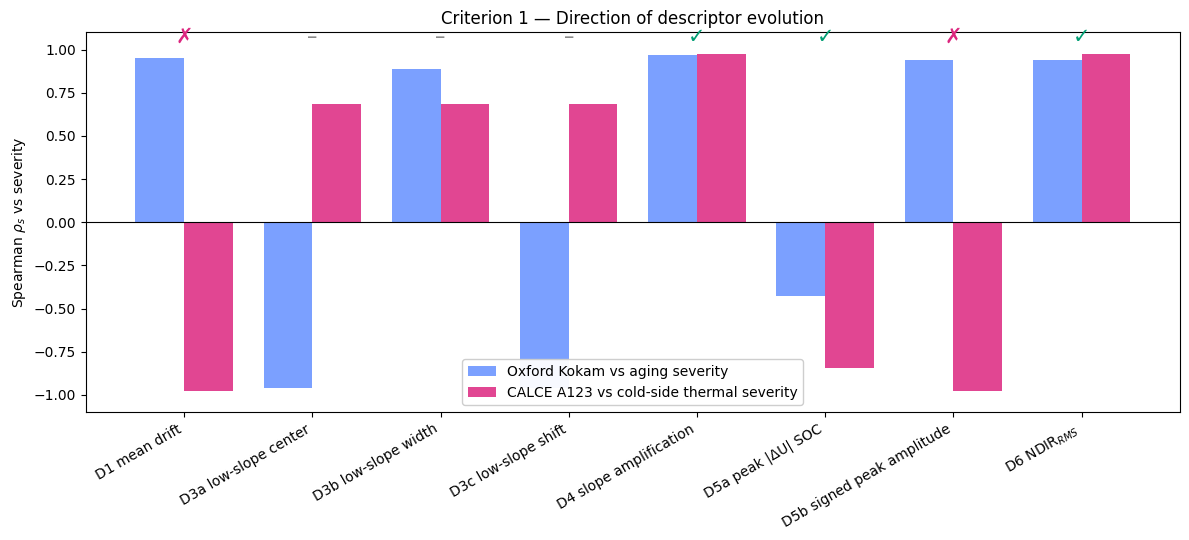

In [41]:
# ---------------------------------------------------------------------
# Criterion 1 figure
# ---------------------------------------------------------------------

OXFORD_C = "#648FFF"
CALCE_C = "#DC267F"

fig, ax = plt.subplots(figsize=(12, 5.5))

x = np.arange(len(crit1_df))
width = 0.38

ax.bar(
    x - width / 2,
    crit1_df["oxford_rho"],
    width,
    color=OXFORD_C,
    alpha=0.85,
    label="Oxford Kokam vs aging severity"
)

ax.bar(
    x + width / 2,
    crit1_df["calce_rho"],
    width,
    color=CALCE_C,
    alpha=0.85,
    label="CALCE A123 vs cold-side thermal severity"
)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(crit1_df["descriptor_label"], rotation=30, ha="right")

ax.set_ylabel(r"Spearman $\rho_s$ vs severity")
ax.set_title("Criterion 1 — Direction of descriptor evolution")
ax.set_ylim(-1.1, 1.1)

for i, verdict in enumerate(crit1_df["criterion1_verdict"]):
    marker = {
        "aligned": "✓",
        "opposite": "✗",
        "inconclusive": "–",
    }[verdict]

    color = {
        "aligned": "#009E73",
        "opposite": "#DC267F",
        "inconclusive": "#888888",
    }[verdict]

    ax.text(i, 1.04, marker, ha="center", fontsize=15, color=color)

ax.legend(loc="best", framealpha=0.95)
plt.tight_layout()

plt.savefig(FIG_DIR / "criterion1_direction_ndir_rms.png")
plt.show()


In [42]:
# Section 6 — Criterion 2: D2 normalized profile comparison
def dataset_profile_d2(local_df, group_col, severity_lookup):
    """
    Average z-score-normalized D2 profile across cell-condition curves,
    weighted by severity.
    """
    profiles = []

    for (cid, cond), g in local_df.groupby(["cell_id", group_col]):
        g = g.sort_values("soc")

        d2 = g["d2_local_drift"].values
        soc = g["soc"].values

        if not np.all(np.isfinite(d2)):
            continue

        mu = np.nanmean(d2)
        sd = np.nanstd(d2)

        if not np.isfinite(sd) or sd < 1e-12:
            continue

        z = (d2 - mu) / sd

        key = (cid, cond)
        w = severity_lookup.get(key, 0.0)

        if w <= 0:
            continue

        profiles.append((soc, z, w))

    if not profiles:
        return None, None

    soc_grid = profiles[0][0]
    weighted_sum = np.zeros_like(soc_grid, dtype=float)
    weight_sum = 0.0

    for soc, z, w in profiles:
        weighted_sum += w * z
        weight_sum += w

    return soc_grid, weighted_sum / weight_sum


In [43]:
# ---------------------------------------------------------------------
# Build severity lookups
# ---------------------------------------------------------------------

ox_sev_lookup = {
    (r.cell_id, r.cycle_key): 1.0 - r.soh
    for r in ox_desc.itertuples()
}

ca_sev_lookup = {
    (r.cell_id, r.temperature_c): T_REF - r.temperature_c
    for r in ca_cold.itertuples()
}

# ---------------------------------------------------------------------
# Compute D2 profiles
# ---------------------------------------------------------------------

soc_grid_ox, prof_ox = dataset_profile_d2(
    ox_local,
    group_col="cycle_key",
    severity_lookup=ox_sev_lookup,
)

ca_local_cold = ca_local[ca_local["temperature_c"] < T_REF].copy()

soc_grid_ca, prof_ca = dataset_profile_d2(
    ca_local_cold,
    group_col="temperature_c",
    severity_lookup=ca_sev_lookup,
)

mask = np.isfinite(prof_ox) & np.isfinite(prof_ca)

rho_p, p_p = pearsonr(prof_ox[mask], prof_ca[mask])
rho_s, p_s = spearmanr(prof_ox[mask], prof_ca[mask])
l2_dist = np.sqrt(np.mean((prof_ox[mask] - prof_ca[mask]) ** 2))

crit2_summary = pd.DataFrame([{
    "pearson": rho_p,
    "pearson_p": p_p,
    "spearman": rho_s,
    "spearman_p": p_s,
    "l2_distance_z_units": l2_dist,
}])

crit2_profiles = pd.DataFrame({
    "soc": soc_grid_ox,
    "oxford_z": prof_ox,
    "calce_z": prof_ca,
})

crit2_summary.to_csv(TABLE_DIR / "criterion2_d2_profile_summary.csv", index=False)
crit2_profiles.to_csv(TABLE_DIR / "criterion2_d2_profiles.csv", index=False)

crit2_summary


,pearson,pearson_p,spearman,spearman_p,l2_distance_z_units
0,-0.297666,0.002769,-0.51039,6.783018e-08,1.560141


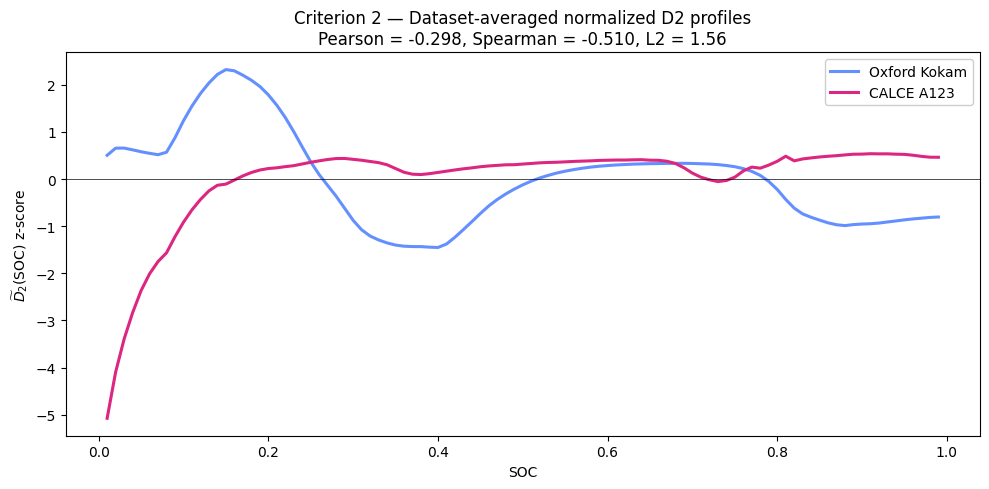

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    soc_grid_ox,
    prof_ox,
    color=OXFORD_C,
    linewidth=2.2,
    label="Oxford Kokam"
)

ax.plot(
    soc_grid_ca,
    prof_ca,
    color=CALCE_C,
    linewidth=2.2,
    label="CALCE A123"
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.7)

ax.set_xlabel("SOC")
ax.set_ylabel(r"$\widetilde{D}_2(\mathrm{SOC})$ z-score")
ax.set_title(
    "Criterion 2 — Dataset-averaged normalized D2 profiles\n"
    f"Pearson = {rho_p:+.3f}, Spearman = {rho_s:+.3f}, "
    f"L2 = {l2_dist:.2f}"
)

ax.legend(loc="best", framealpha=0.95)

plt.tight_layout()
plt.savefig(FIG_DIR / "criterion2_d2_profile_comparison.png")
plt.show()


In [45]:
# Section 7 — Criterion 3: peak-deformation SOC location
ox_maxdef = ox_desc["d5_peak_soc"].dropna()
ca_maxdef = ca_cold["d5_peak_soc"].dropna()

ox_lo, ox_hi = ox_maxdef.quantile([0.25, 0.75])
ca_lo, ca_hi = ca_maxdef.quantile([0.25, 0.75])

overlap = max(0, min(ox_hi, ca_hi) - max(ox_lo, ca_lo))
union = max(ox_hi, ca_hi) - min(ox_lo, ca_lo)

iqr_iou = overlap / union if union > 0 else 0.0

if iqr_iou > 0.30:
    verdict = "shared SOC region"
elif iqr_iou > 0.05:
    verdict = "partial overlap"
else:
    verdict = "disjoint SOC regions"

crit3_df = pd.DataFrame([{
    "oxford_median": ox_maxdef.median(),
    "oxford_iqr_lo": ox_lo,
    "oxford_iqr_hi": ox_hi,
    "calce_median": ca_maxdef.median(),
    "calce_iqr_lo": ca_lo,
    "calce_iqr_hi": ca_hi,
    "iqr_iou": iqr_iou,
    "verdict": verdict,
    "n_oxford": len(ox_maxdef),
    "n_calce_cold": len(ca_maxdef),
}])

crit3_df.to_csv(TABLE_DIR / "criterion3_peak_soc_overlap.csv", index=False)

crit3_df


,oxford_median,oxford_iqr_lo,oxford_iqr_hi,calce_median,calce_iqr_lo,calce_iqr_hi,iqr_iou,verdict,n_oxford,n_calce_cold
0,0.16,0.15,0.16,0.405,0.1,0.7175,0.016194,disjoint SOC regions,496,8


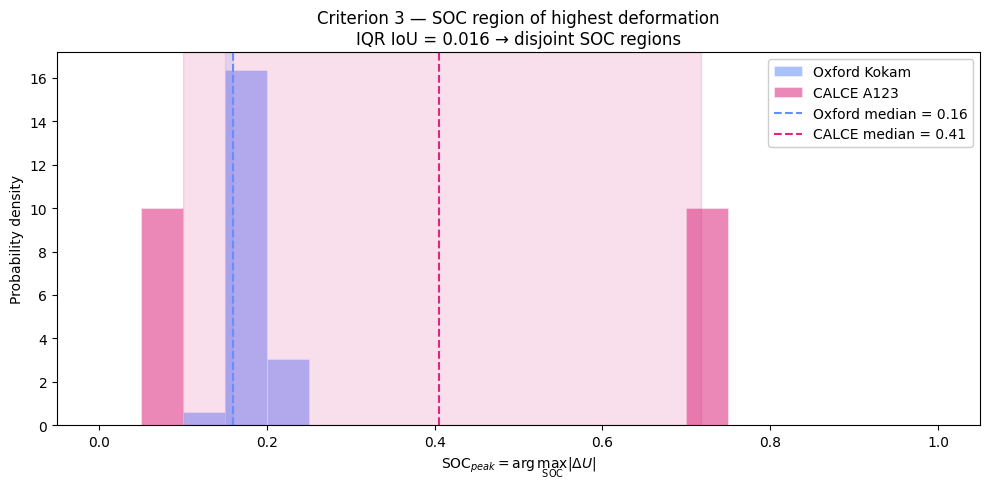

In [46]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0, 1, 21)

ax.hist(
    ox_maxdef,
    bins=bins,
    alpha=0.55,
    color=OXFORD_C,
    density=True,
    edgecolor="white",
    linewidth=0.5,
    label="Oxford Kokam"
)

ax.hist(
    ca_maxdef,
    bins=bins,
    alpha=0.55,
    color=CALCE_C,
    density=True,
    edgecolor="white",
    linewidth=0.5,
    label="CALCE A123"
)

ax.axvspan(ox_lo, ox_hi, color=OXFORD_C, alpha=0.15)
ax.axvspan(ca_lo, ca_hi, color=CALCE_C, alpha=0.15)

ax.axvline(
    ox_maxdef.median(),
    color=OXFORD_C,
    linestyle="--",
    linewidth=1.5,
    label=f"Oxford median = {ox_maxdef.median():.2f}"
)

ax.axvline(
    ca_maxdef.median(),
    color=CALCE_C,
    linestyle="--",
    linewidth=1.5,
    label=f"CALCE median = {ca_maxdef.median():.2f}"
)

ax.set_xlabel(r"$\mathrm{SOC}_{peak} = \arg\max_{\mathrm{SOC}} |\Delta U|$")
ax.set_ylabel("Probability density")
ax.set_title(
    "Criterion 3 — SOC region of highest deformation\n"
    f"IQR IoU = {iqr_iou:.3f} → {verdict}"
)

ax.legend(loc="best", framealpha=0.95)

plt.tight_layout()
plt.savefig(FIG_DIR / "criterion3_peak_deformation_soc.png")
plt.show()


In [47]:
# Section 8 — Criterion 4: corrected NDIR_rms power law fits
def power_law(s, a, b):
    return a * np.power(np.maximum(s, 1e-12), b)


def fit_power_law(s, y):
    s = np.asarray(s, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (
        (s > 1e-9)
        & np.isfinite(s)
        & np.isfinite(y)
        & (y > 0)
    )

    s = s[mask]
    y = y[mask]

    if len(s) < 4:
        return None

    popt, pcov = curve_fit(
        power_law,
        s,
        y,
        p0=[0.1, 1.0],
        bounds=([1e-8, 0.05], [10.0, 5.0]),
        maxfev=10000,
    )

    a, b = popt
    pred = power_law(s, a, b)

    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)

    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rho_s, p_s = spearmanr(s, y)

    se = np.sqrt(np.diag(pcov)) if pcov is not None else [np.nan, np.nan]

    return {
        "a": a,
        "b": b,
        "a_se": se[0],
        "b_se": se[1],
        "r2": r2,
        "rho_s": rho_s,
        "p_value": p_s,
        "n": len(s),
    }


In [48]:
fits = []

ox_fit = fit_power_law(
    ox_desc["severity"],
    ox_desc[D6_COL],
)

if ox_fit is not None:
    fits.append({
        "dataset": "Oxford Kokam",
        "severity_definition": "s = 1 - SOH",
        **ox_fit,
    })

ca_fit = fit_power_law(
    ca_cold["severity_norm"],
    ca_cold[D6_COL],
)

if ca_fit is not None:
    fits.append({
        "dataset": "CALCE A123 cold side",
        "severity_definition": "s = (T_ref - T) / 35",
        **ca_fit,
    })

crit4_df = pd.DataFrame(fits)

crit4_df.to_csv(TABLE_DIR / "criterion4_powerlaw_ndir_rms.csv", index=False)

crit4_df


,dataset,severity_definition,a,b,a_se,b_se,r2,rho_s,p_value,n
0,Oxford Kokam,s = 1 - SOH,0.116607,0.803887,0.003279,0.015364,0.911529,0.938296,6.050728e-230,496
1,CALCE A123 cold side,s = (T_ref - T) / 35,0.212819,2.447400,0.014548,0.410998,0.946723,0.975900,3.436403e-05,8


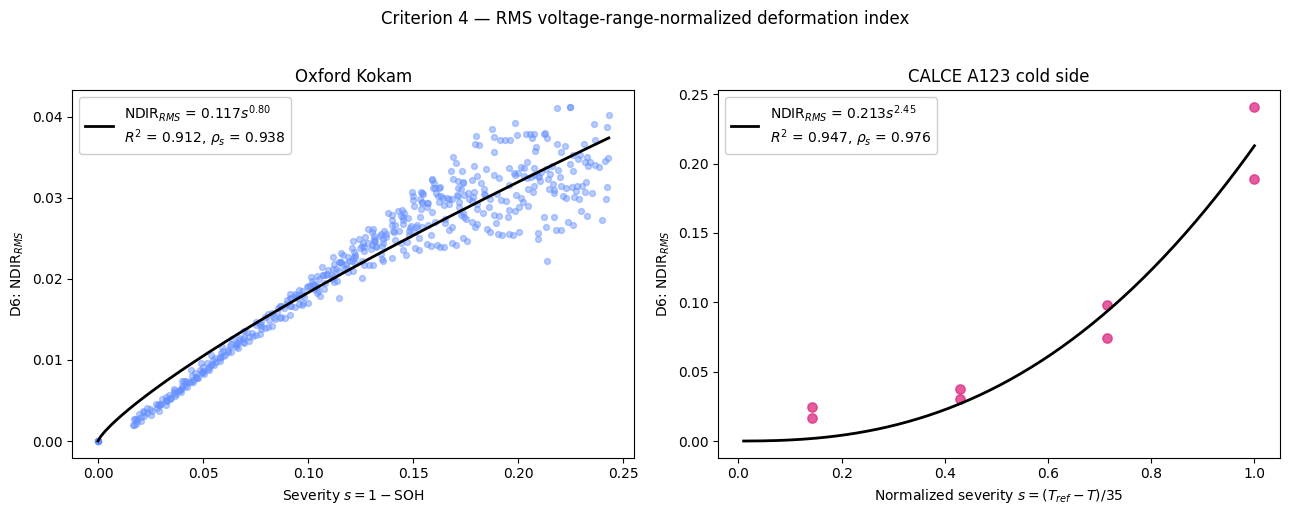

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

# ---------------------------------------------------------------------
# Oxford
# ---------------------------------------------------------------------

ax = axes[0]

ax.scatter(
    ox_desc["severity"],
    ox_desc[D6_COL],
    color=OXFORD_C,
    alpha=0.45,
    s=18,
)

if ox_fit is not None:
    s_smooth = np.linspace(
        ox_desc["severity"].min(),
        ox_desc["severity"].max(),
        200,
    )

    ax.plot(
        s_smooth,
        power_law(s_smooth, ox_fit["a"], ox_fit["b"]),
        color="black",
        linewidth=2,
        label=(
            rf"NDIR$_{{RMS}}$ = {ox_fit['a']:.3f}"
            rf"$s^{{{ox_fit['b']:.2f}}}$"
            "\n"
            rf"$R^2$ = {ox_fit['r2']:.3f}, "
            rf"$\rho_s$ = {ox_fit['rho_s']:.3f}"
        ),
    )

ax.set_xlabel(r"Severity $s = 1 - \mathrm{SOH}$")
ax.set_ylabel(r"D6: NDIR$_{RMS}$")
ax.set_title("Oxford Kokam")
ax.legend(loc="best", framealpha=0.95)

# ---------------------------------------------------------------------
# CALCE
# ---------------------------------------------------------------------

ax = axes[1]

ax.scatter(
    ca_cold["severity_norm"],
    ca_cold[D6_COL],
    color=CALCE_C,
    alpha=0.75,
    s=45,
)

if ca_fit is not None:
    s_smooth = np.linspace(0.01, 1.0, 200)

    ax.plot(
        s_smooth,
        power_law(s_smooth, ca_fit["a"], ca_fit["b"]),
        color="black",
        linewidth=2,
        label=(
            rf"NDIR$_{{RMS}}$ = {ca_fit['a']:.3f}"
            rf"$s^{{{ca_fit['b']:.2f}}}$"
            "\n"
            rf"$R^2$ = {ca_fit['r2']:.3f}, "
            rf"$\rho_s$ = {ca_fit['rho_s']:.3f}"
        ),
    )

ax.set_xlabel(r"Normalized severity $s = (T_{ref}-T)/35$")
ax.set_ylabel(r"D6: NDIR$_{RMS}$")
ax.set_title("CALCE A123 cold side")
ax.legend(loc="best", framealpha=0.95)

fig.suptitle(
    r"Criterion 4 — RMS voltage-range-normalized deformation index",
    y=1.02,
)

plt.tight_layout()
plt.savefig(FIG_DIR / "criterion4_ndir_rms_powerlaw.png")
plt.show()


In [49]:
# Section 9 — Criterion 5: GP uncertainty summary
# ---------------------------------------------------------------------
# Rename uncertainty columns to make RMS meaning explicit
# ---------------------------------------------------------------------

ox_unc = ox_unc.copy()
ca_unc = ca_unc.copy()

ox_unc = ox_unc.rename(columns={
    "ndi_mean": "ndir_rms_mean",
    "ndi_ci_lo": "ndir_rms_ci_lo",
    "ndi_ci_hi": "ndir_rms_ci_hi",
})

ca_unc = ca_unc.rename(columns={
    "ndi_mean": "ndir_rms_mean",
    "ndi_ci_lo": "ndir_rms_ci_lo",
    "ndi_ci_hi": "ndir_rms_ci_hi",
})


In [50]:
# ---------------------------------------------------------------------
# Relative CI width
# ---------------------------------------------------------------------

for df in [ox_unc, ca_unc]:
    df["ndir_rms_ci_width"] = df["ndir_rms_ci_hi"] - df["ndir_rms_ci_lo"]
    df["ndir_rms_rel_ci_width"] = (
        df["ndir_rms_ci_width"]
        / df["ndir_rms_mean"].replace(0, np.nan)
    )

unc_summary = pd.DataFrame([
    {
        "dataset": "Oxford Kokam",
        "median_rel_ci_width": ox_unc["ndir_rms_rel_ci_width"].median(),
        "iqr_lo_rel_ci_width": ox_unc["ndir_rms_rel_ci_width"].quantile(0.25),
        "iqr_hi_rel_ci_width": ox_unc["ndir_rms_rel_ci_width"].quantile(0.75),
    },
    {
        "dataset": "CALCE A123",
        "median_rel_ci_width": ca_unc["ndir_rms_rel_ci_width"].median(),
        "iqr_lo_rel_ci_width": ca_unc["ndir_rms_rel_ci_width"].quantile(0.25),
        "iqr_hi_rel_ci_width": ca_unc["ndir_rms_rel_ci_width"].quantile(0.75),
    },
])

unc_summary.to_csv(TABLE_DIR / "criterion5_uncertainty_summary.csv", index=False)

unc_summary


,dataset,median_rel_ci_width,iqr_lo_rel_ci_width,iqr_hi_rel_ci_width
0,Oxford Kokam,0.036185,0.023259,0.080880
1,CALCE A123,0.192379,0.006845,0.385022


In [51]:
# ---------------------------------------------------------------------
# GP performance summary
# ---------------------------------------------------------------------

gp_summary_rows = []

gp_summary_rows.append({
    "dataset": "Oxford Kokam",
    "regime": "stratified leave-one-aging-state-out",
    "rmse_mv_mean": ox_gp["rmse_mv"].mean(),
    "mae_mv_mean": ox_gp["mae_mv"].mean(),
    "coverage_95_mean": ox_gp["coverage_95"].mean(),
    "n_rows": len(ox_gp),
})

ca_int = ca_gp[ca_gp["regime"] == "interior"]
ca_edge = ca_gp[ca_gp["regime"] == "edge"]

gp_summary_rows.append({
    "dataset": "CALCE A123",
    "regime": "interior LOTO",
    "rmse_mv_mean": ca_int["rmse_mv"].mean(),
    "mae_mv_mean": ca_int["mae_mv"].mean(),
    "coverage_95_mean": ca_int["coverage_95"].mean(),
    "n_rows": len(ca_int),
})

gp_summary_rows.append({
    "dataset": "CALCE A123",
    "regime": "edge LOTO",
    "rmse_mv_mean": ca_edge["rmse_mv"].mean(),
    "mae_mv_mean": ca_edge["mae_mv"].mean(),
    "coverage_95_mean": ca_edge["coverage_95"].mean(),
    "n_rows": len(ca_edge),
})

gp_summary = pd.DataFrame(gp_summary_rows)

gp_summary.to_csv(TABLE_DIR / "gp_validation_summary.csv", index=False)

gp_summary


,dataset,regime,rmse_mv_mean,mae_mv_mean,coverage_95_mean,n_rows
0,Oxford Kokam,stratified leave-one-aging-state-out,2.782584,1.287260,0.920581,8
1,CALCE A123,interior LOTO,24.428373,17.583116,0.952862,2
2,CALCE A123,edge LOTO,49.803701,37.233158,0.992424,2


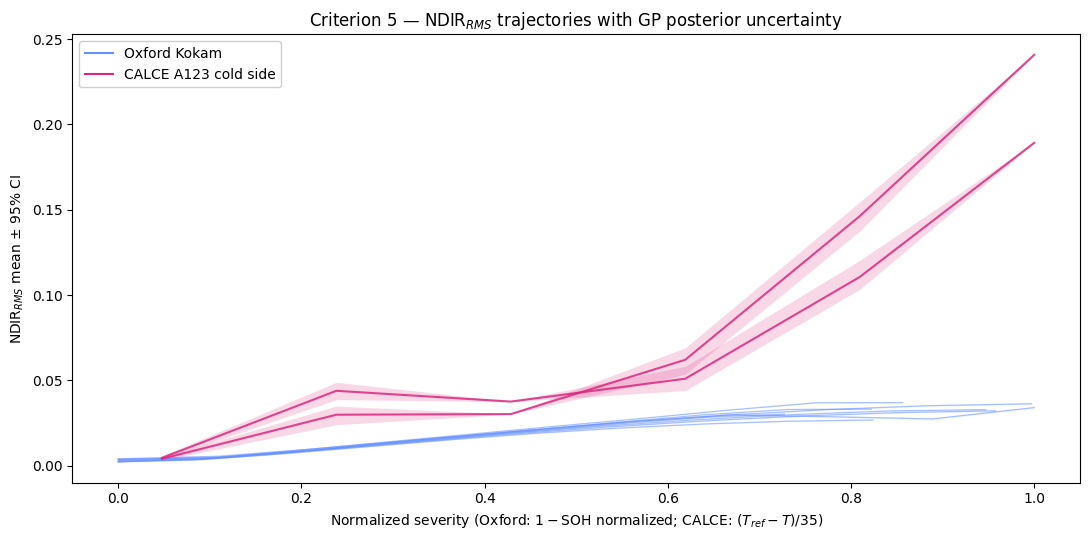

In [52]:
# ---------------------------------------------------------------------
# Uncertainty overlay figure
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5.5))

# Oxford trajectories
for cid, g in ox_unc.groupby("cell_id"):
    g = g.sort_values("soh", ascending=False).copy()
    g["severity_norm"] = (1.0 - g["soh"]) / ox_desc["severity"].max()

    ax.fill_between(
        g["severity_norm"],
        g["ndir_rms_ci_lo"],
        g["ndir_rms_ci_hi"],
        color=OXFORD_C,
        alpha=0.08,
        linewidth=0,
    )

    ax.plot(
        g["severity_norm"],
        g["ndir_rms_mean"],
        color=OXFORD_C,
        alpha=0.55,
        linewidth=0.9,
    )

# CALCE cold-side trajectories
ca_unc_cold = ca_unc[ca_unc["temperature_c"] < T_REF].copy()

for cid, g in ca_unc_cold.groupby("cell_id"):
    g = g.sort_values("temperature_c").copy()
    g["severity_norm"] = (T_REF - g["temperature_c"]) / CALCE_COLD_SPAN

    ax.fill_between(
        g["severity_norm"],
        g["ndir_rms_ci_lo"],
        g["ndir_rms_ci_hi"],
        color=CALCE_C,
        alpha=0.18,
        linewidth=0,
    )

    ax.plot(
        g["severity_norm"],
        g["ndir_rms_mean"],
        color=CALCE_C,
        alpha=0.85,
        linewidth=1.5,
    )

# Legend handles
ax.plot([], [], color=OXFORD_C, linewidth=1.5, label="Oxford Kokam")
ax.plot([], [], color=CALCE_C, linewidth=1.5, label="CALCE A123 cold side")

ax.set_xlabel(
    "Normalized severity "
    r"(Oxford: $1-\mathrm{SOH}$ normalized; "
    r"CALCE: $(T_{ref}-T)/35$)"
)

ax.set_ylabel(r"NDIR$_{RMS}$ mean ± 95% CI")
ax.set_title(
    r"Criterion 5 — NDIR$_{RMS}$ trajectories with GP posterior uncertainty"
)

ax.legend(loc="best", framealpha=0.95)

plt.tight_layout()
plt.savefig(FIG_DIR / "criterion5_ndir_rms_uncertainty_overlay.png")
plt.show()


In [53]:
# Section 10 — Final descriptor-level classification table
classification_rows = [
    {
        "descriptor": "D1 mean drift",
        "verdict": "Stressor-/chemistry-specific",
        "basis": "Opposite directional evolution and cancellation of SOC-local deformation.",
    },
    {
        "descriptor": "D2 SOC-local drift profile",
        "verdict": "Sign stressor-/chemistry-specific; shared low-SOC localization",
        "basis": (
            f"Dataset-averaged normalized profiles are anti-correlated "
            f"(Pearson = {rho_p:+.2f}, Spearman = {rho_s:+.2f}), "
            "but both show important low-SOC deformation."
        ),
    },
    {
        "descriptor": "D3a low-slope center",
        "verdict": "Inconclusive",
        "basis": "Limited CALCE cold-side statistical power and threshold sensitivity.",
    },
    {
        "descriptor": "D3b low-slope width",
        "verdict": "Inconclusive",
        "basis": "Adaptive percentile threshold makes width sensitive to descriptor definition.",
    },
    {
        "descriptor": "D3c low-slope shift",
        "verdict": "Inconclusive",
        "basis": "Oxford shows aging-related migration, but CALCE cold-side migration is weak.",
    },
    {
        "descriptor": "D4 slope amplification",
        "verdict": "Candidate portable geometric descriptor",
        "basis": "Direction aligned across datasets; interpretation requires delta-sensitivity reporting.",
    },
    {
        "descriptor": "D5a peak |ΔU| SOC location",
        "verdict": "Partially aligned",
        "basis": (
            f"Directional behavior partly aligned, but absolute SOC regions are largely disjoint "
            f"(IQR IoU = {iqr_iou:.3f})."
        ),
    },
    {
        "descriptor": "D5b signed peak amplitude",
        "verdict": "Stressor-/chemistry-specific",
        "basis": "Signed peak amplitude has opposite sign across Oxford aging and CALCE cold-side response.",
    },
    {
        "descriptor": r"D6 NDIR$_{RMS}$",
        "verdict": "Candidate portable geometric descriptor",
        "basis": "Monotonic growth aligned across datasets; power-law growth rate remains condition-specific.",
    },
]

classification_df = pd.DataFrame(classification_rows)

classification_df.to_csv(
    TABLE_DIR / "final_descriptor_classification.csv",
    index=False,
)

classification_df


,descriptor,verdict,basis
0,D1 mean drift,Stressor-/chemistry-specific,Opposite directional evolution and cancellatio...
1,D2 SOC-local drift profile,Sign stressor-/chemistry-specific; shared low-...,Dataset-averaged normalized profiles are anti-...
2,D3a low-slope center,Inconclusive,Limited CALCE cold-side statistical power and ...
3,D3b low-slope width,Inconclusive,Adaptive percentile threshold makes width sens...
4,D3c low-slope shift,Inconclusive,"Oxford shows aging-related migration, but CALC..."
5,D4 slope amplification,Candidate portable geometric descriptor,Direction aligned across datasets; interpretat...
6,D5a peak |ΔU| SOC location,Partially aligned,"Directional behavior partly aligned, but absol..."
7,D5b signed peak amplitude,Stressor-/chemistry-specific,Signed peak amplitude has opposite sign across...
8,D6 NDIR$_{RMS}$,Candidate portable geometric descriptor,Monotonic growth aligned across datasets; powe...


In [28]:
# Section 11 — Print manuscript-ready numerical summary
print("=" * 80)
print("MANUSCRIPT-READY SUMMARY")
print("=" * 80)

print("\nNDIR audit:")
print(ndir_audit_df.to_string(index=False))

print("\nCriterion 1:")
print(
    crit1_df[
        [
            "descriptor_label",
            "oxford_rho",
            "oxford_p",
            "calce_rho",
            "calce_p",
            "criterion1_verdict",
        ]
    ].to_string(index=False)
)

print("\nCriterion 2 D2 profile comparison:")
print(crit2_summary.to_string(index=False))

print("\nCriterion 3 peak SOC overlap:")
print(crit3_df.to_string(index=False))

print("\nCriterion 4 NDIR_RMS power-law fits:")
print(crit4_df.to_string(index=False))

print("\nCriterion 5 GP summary:")
print(gp_summary.to_string(index=False))

print("\nFinal descriptor classification:")
print(classification_df.to_string(index=False))


MANUSCRIPT-READY SUMMARY

NDIR audit:
     dataset  n_rows  expected_sqrt_N  median_L2_over_RMS  mean_L2_over_RMS  std_L2_over_RMS  max_NDI_L2  max_NDIR_RMS
Oxford Kokam     504         9.949874            9.949874          9.949874     1.614868e-14    0.410105      0.041217
  CALCE A123      16         9.949874            9.949874          9.949874     1.101650e-15    2.395270      0.240734

Criterion 1:
         descriptor_label  oxford_rho      oxford_p  calce_rho  calce_p criterion1_verdict
            D1 mean drift    0.952627 1.188515e-261  -0.975900 0.000034           opposite
     D3a low-slope center   -0.961028 1.823759e-282   0.683130 0.061835       inconclusive
      D3b low-slope width    0.888415 7.116025e-172   0.687233 0.059669       inconclusive
      D3c low-slope shift   -0.961028 1.823759e-282   0.683130 0.061835       inconclusive
   D4 slope amplification    0.966467 1.492856e-298   0.975900 0.000034            aligned
        D5a peak |ΔU| SOC   -0.427979  1.6467